# ĐỒ ÁN HỌC MÁY: CHẨN ĐOÁN BỆNH THẬN


### Phần 1 — Setup & Import Thư viện
Import các thư viện xử lý dữ liệu, phân tách tập train/test, mô hình cây, tối ưu siêu tham số, trực quan hóa và lưu trữ mô hình.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# LightGBM
from lightgbm import LGBMClassifier

# Cấu hình cảnh báo & hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Tạo thư mục outputs nếu chưa có
os.makedirs('outputs', exist_ok=True)

print("✅ Setup & Import thư viện thành công!")


✅ Setup & Import thư viện thành công!


### Phần 2 — Đọc Dữ liệu Đã Xử lý
- Đọc file dữ liệu đầu vào `data/clean_KidneyDisease_data.csv`.
- Kiểm tra kích thước dữ liệu (`.shape`).
- Kiểm tra giá trị khuyết thiếu (`.isnull().sum()`) — đảm bảo 100% không còn missing values.
- Kiểm tra kiểu dữ liệu (`.dtypes`) — đảm bảo toàn bộ đã được mã hóa sang dạng số.


In [ ]:
# Đọc file dữ liệu 
data_path = 'data/clean_KidneyDisease_data.csv'
df = pd.read_csv(data_path)

print(f"📊 Kích thước dữ liệu (Shape): {df.shape[0]} dòng, {df.shape[1]} cột")

# 1. Kiểm tra giá trị khuyết thiếu
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("✅ Kiểm tra Missing Values: ĐẠT (Không còn giá trị khuyết thiếu)")
else:
    print(f"❌ CẢNH BÁO: Còn {missing_count} giá trị thiếu cần xử lý!")
    display(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Kiểm tra kiểu dữ liệu chuỗi (object)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
if len(object_cols) == 0:
    print("✅ Kiểm tra Dtypes: ĐẠT (100% các cột đã được mã hóa sang dạng số)")
else:
    print(f"❌ CẢNH BÁO: Còn {len(object_cols)} cột kiểu chữ chưa encode: {object_cols}")

# Hiển thị 5 dòng đầu tiên
df.head()


📊 Kích thước dữ liệu (Shape): 397 dòng, 25 cột
✅ Kiểm tra Missing Values: ĐẠT (Không còn giá trị khuyết thiếu)
✅ Kiểm tra Dtypes: ĐẠT (100% các cột đã được mã hóa sang dạng số)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,1,0,0,1,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,1,0,0,1,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,1,2,0,2,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,1,2,1,2,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,1,0,0,1,0


### Phần 3 — Chia Tập Train / Test
- Tách ma trận đặc trưng $X$ (bỏ cột nhãn `class`) và nhãn mục tiêu $y$.
- Sử dụng `train_test_split` với tỷ lệ:
  - `test_size = 0.2` (80% Train — 20% Test)
  - `random_state = 42` (Đảm bảo tính tái lập)
  - `stratify = y` (**Bắt buộc**: bảo toàn tỷ lệ lớp bệnh/khỏe giữa 2 tập do dữ liệu mất cân bằng)
- **Lưu ý y khoa**: Trong dataset, `class = 0` là CKD (Có bệnh), `class = 1` là NotCKD (Không bệnh/Khỏe mạnh).


In [3]:
TARGET_COL = 'class'

# Tách X và y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Phân chia train/test có stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Số lượng mẫu tập Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Số lượng mẫu tập Test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("-" * 50)

# Kiểm tra tỷ lệ phân phối nhãn
train_dist = y_train.value_counts(normalize=True).round(4) * 100
test_dist = y_test.value_counts(normalize=True).round(4) * 100

dist_df = pd.DataFrame({
    'Train (%)': train_dist,
    'Test (%)': test_dist
})
dist_df.index = [f"Class {idx} ({'CKD - Có bệnh' if idx == 0 else 'NotCKD - Khỏe'})" for idx in dist_df.index]
print("Tỷ lệ phân bố nhãn (Stratified Verification):")
display(dist_df)


Số lượng mẫu tập Train: 317 (79.8%)
Số lượng mẫu tập Test:  80 (20.2%)
--------------------------------------------------
Tỷ lệ phân bố nhãn (Stratified Verification):


,Train (%),Test (%)
Class 0 (CKD - Có bệnh),62.46,62.5
Class 1 (NotCKD - Khỏe),37.54,37.5


### Phần 4 — Mô hình 1: Decision Tree (Baseline)
- Khởi tạo `DecisionTreeClassifier(random_state=42)` với các tham số mặc định.
- Huấn luyện trên tập Train và dự đoán trên tập Test.
- Decision Tree dùng làm mô hình chuẩn cơ sở (Baseline) để so sánh với các kỹ thuật ensemble phức tạp hơn.


In [4]:
# Khởi tạo mô hình Decision Tree mặc định
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Dự đoán và tính accuracy
dt_preds = dt_baseline.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"🌲 Decision Tree Baseline Accuracy: {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"   - Độ sâu tối đa của cây (Max Depth): {dt_baseline.get_depth()}")
print(f"   - Số lượng nút lá (Leaf Nodes): {dt_baseline.get_n_leaves()}")


🌲 Decision Tree Baseline Accuracy: 0.9375 (93.75%)
   - Độ sâu tối đa của cây (Max Depth): 5
   - Số lượng nút lá (Leaf Nodes): 9


### Phần 5 — Mô hình 2: Random Forest (Baseline)
- Khởi tạo `RandomForestClassifier(random_state=42)` với các tham số mặc định.
- Kỹ thuật Bagging kết hợp Feature Subsampling giúp giảm variance và hạn chế tối đa nguy cơ overfitting của cây đơn lẻ.


In [5]:
# Khởi tạo mô hình Random Forest mặc định
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# Dự đoán và tính accuracy
rf_preds = rf_baseline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"🌳 Random Forest Baseline Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"   - Số lượng cây (n_estimators): {rf_baseline.n_estimators}")


🌳 Random Forest Baseline Accuracy: 0.9750 (97.50%)
   - Số lượng cây (n_estimators): 100


### Phần 6 — Mô hình 3: LightGBM (Baseline)
- Khởi tạo `LGBMClassifier(random_state=42, verbose=-1)` với các tham số mặc định.
- Thuật toán Gradient Boosting theo cơ chế Leaf-wise growth, học tuần tự để tối ưu hóa hàm mất mát và khắc phục sai lầm của các cây trước.


In [6]:
# Khởi tạo mô hình LightGBM mặc định
lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)
lgbm_baseline.fit(X_train, y_train)

# Dự đoán và tính accuracy
lgbm_preds = lgbm_baseline.predict(X_test)
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"⚡ LightGBM Baseline Accuracy: {lgbm_acc:.4f} ({lgbm_acc*100:.2f}%)")


⚡ LightGBM Baseline Accuracy: 0.9875 (98.75%)


### Phần 7 — Tối ưu Siêu Tham Số (Hyperparameter Tuning)
Tối ưu hóa các siêu tham số quan trọng cho Random Forest và LightGBM bằng kỹ thuật Cross-Validation (5-Fold) để tìm cấu hình cho độ khái quát hóa cao nhất.
- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`.
- **LightGBM:** `num_leaves`, `learning_rate`, `n_estimators`.


In [7]:
# 7.1 Tối ưu siêu tham số cho Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

print("🔄 Đang tối ưu siêu tham số Random Forest qua 5-Fold Cross Validation...")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_best_preds = rf_best.predict(X_test)
rf_best_acc = accuracy_score(y_test, rf_best_preds)

print(f"✅ Random Forest - Best Params: {rf_grid.best_params_}")
print(f"✅ Random Forest - Best CV Score: {rf_grid.best_score_:.4f}")
print(f"🎯 Random Forest - Test Accuracy (Sau tối ưu): {rf_best_acc:.4f} ({rf_best_acc*100:.2f}%)")
print("-" * 60)

# 7.2 Tối ưu siêu tham số cho LightGBM
lgbm_param_grid = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

print("🔄 Đang tối ưu siêu tham số LightGBM qua 5-Fold Cross Validation...")
lgbm_grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=0
)
lgbm_grid.fit(X_train, y_train)

lgbm_best = lgbm_grid.best_estimator_
lgbm_best_preds = lgbm_best.predict(X_test)
lgbm_best_acc = accuracy_score(y_test, lgbm_best_preds)

print(f"✅ LightGBM - Best Params: {lgbm_grid.best_params_}")
print(f"✅ LightGBM - Best CV Score: {lgbm_grid.best_score_:.4f}")
print(f"🎯 LightGBM - Test Accuracy (Sau tối ưu): {lgbm_best_acc:.4f} ({lgbm_best_acc*100:.2f}%)")


🔄 Đang tối ưu siêu tham số Random Forest qua 5-Fold Cross Validation...
✅ Random Forest - Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
✅ Random Forest - Best CV Score: 0.9905
🎯 Random Forest - Test Accuracy (Sau tối ưu): 0.9750 (97.50%)
------------------------------------------------------------
🔄 Đang tối ưu siêu tham số LightGBM qua 5-Fold Cross Validation...
✅ LightGBM - Best Params: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 20}
✅ LightGBM - Best CV Score: 0.9874
🎯 LightGBM - Test Accuracy (Sau tối ưu): 0.9875 (98.75%)


### Phần 8 — Xuất Hình ảnh Cấu trúc Decision Tree
- Trực quan hóa cây quyết định bằng hàm `plot_tree()`.
- Giới hạn `max_depth=3` để cấu trúc hiển thị rõ ràng, phục vụ minh họa cho **Chương 5.2: Giải thích luật chẩn đoán lâm sàng**.
- Xuất file ra `outputs/decision_tree_structure.png`.


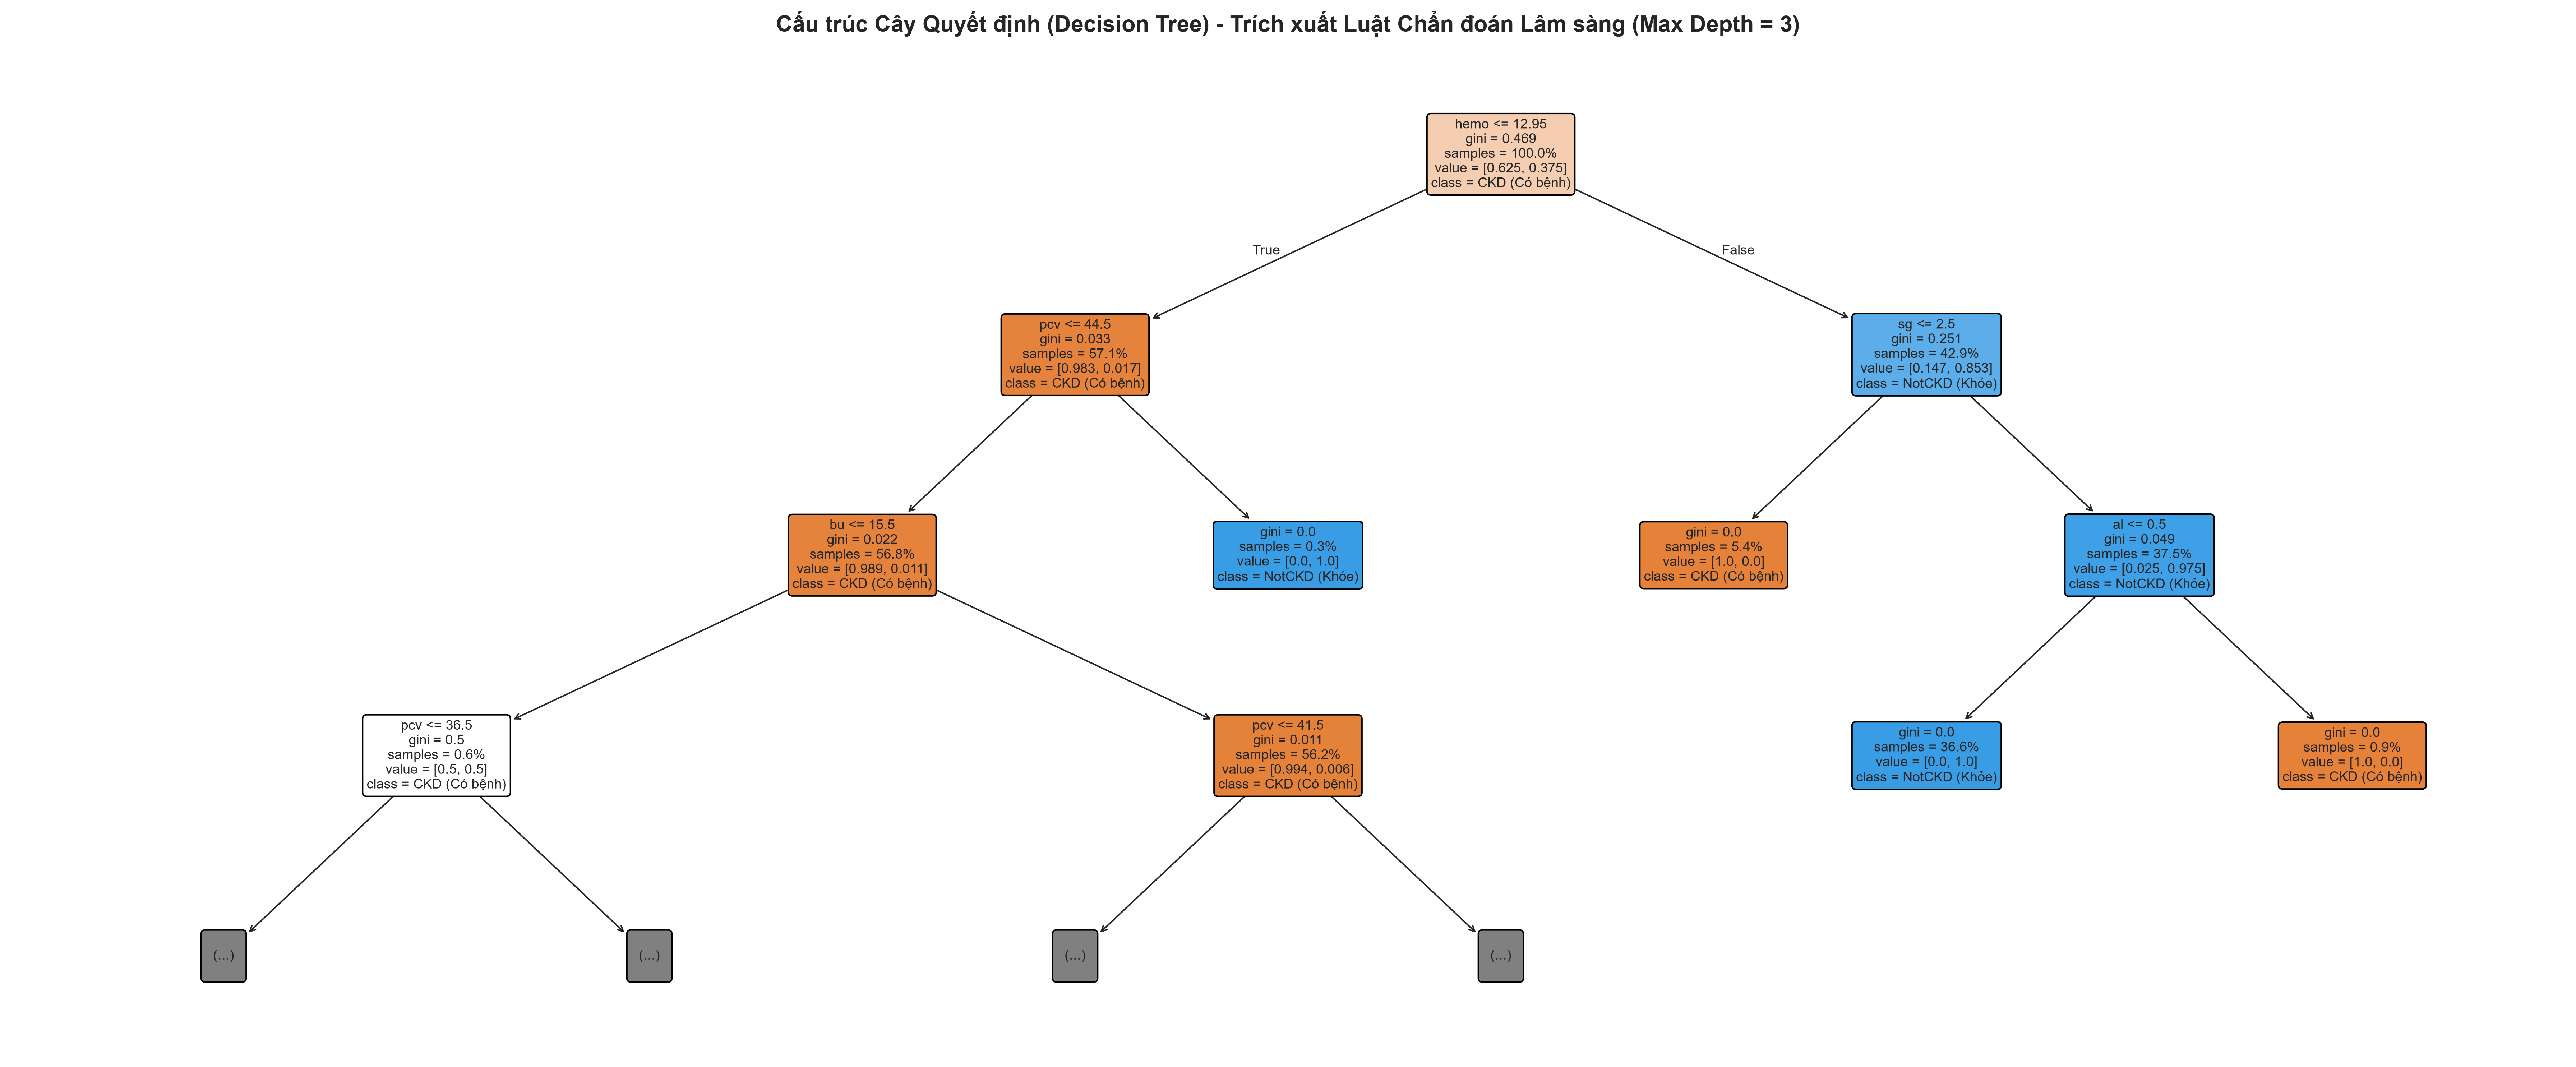

📸 Đã lưu hình ảnh cấu trúc cây tại: outputs/decision_tree_structure.png


In [8]:
# Trực quan hóa cấu trúc Decision Tree
plt.figure(figsize=(24, 10), dpi=300)

class_labels = ['CKD (Có bệnh)', 'NotCKD (Khỏe)']

plot_tree(
    dt_baseline,
    feature_names=X.columns.tolist(),
    class_names=class_labels,
    filled=True,
    rounded=True,
    max_depth=3,        # Giới hạn 3 tầng để biểu đồ rõ ràng, phục vụ báo cáo
    fontsize=9,
    proportion=True
)

plt.title("Cấu trúc Cây Quyết định (Decision Tree) - Trích xuất Luật Chẩn đoán Lâm sàng (Max Depth = 3)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()

# Lưu hình ảnh
dt_img_path = 'outputs/decision_tree_structure.png'
plt.savefig(dt_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Đã lưu hình ảnh cấu trúc cây tại: {dt_img_path}")


### Phần 9 — Biểu đồ Độ quan trọng Đặc trưng (Feature Importance)
- So sánh hiệu năng giữa Random Forest và LightGBM đã tối ưu để chọn ra mô hình xuất sắc nhất.
- Trích xuất `feature_importances_`, sắp xếp giảm dần và trực quan hóa bằng barplot.
- Hình ảnh này phục vụ viết **Chương 5.3: Phân tích các đặc trưng quan trọng**.
- Xuất file ra `outputs/feature_importance.png`.


📌 Sử dụng mô hình [LightGBM (Tuned)] để trích xuất Feature Importance.


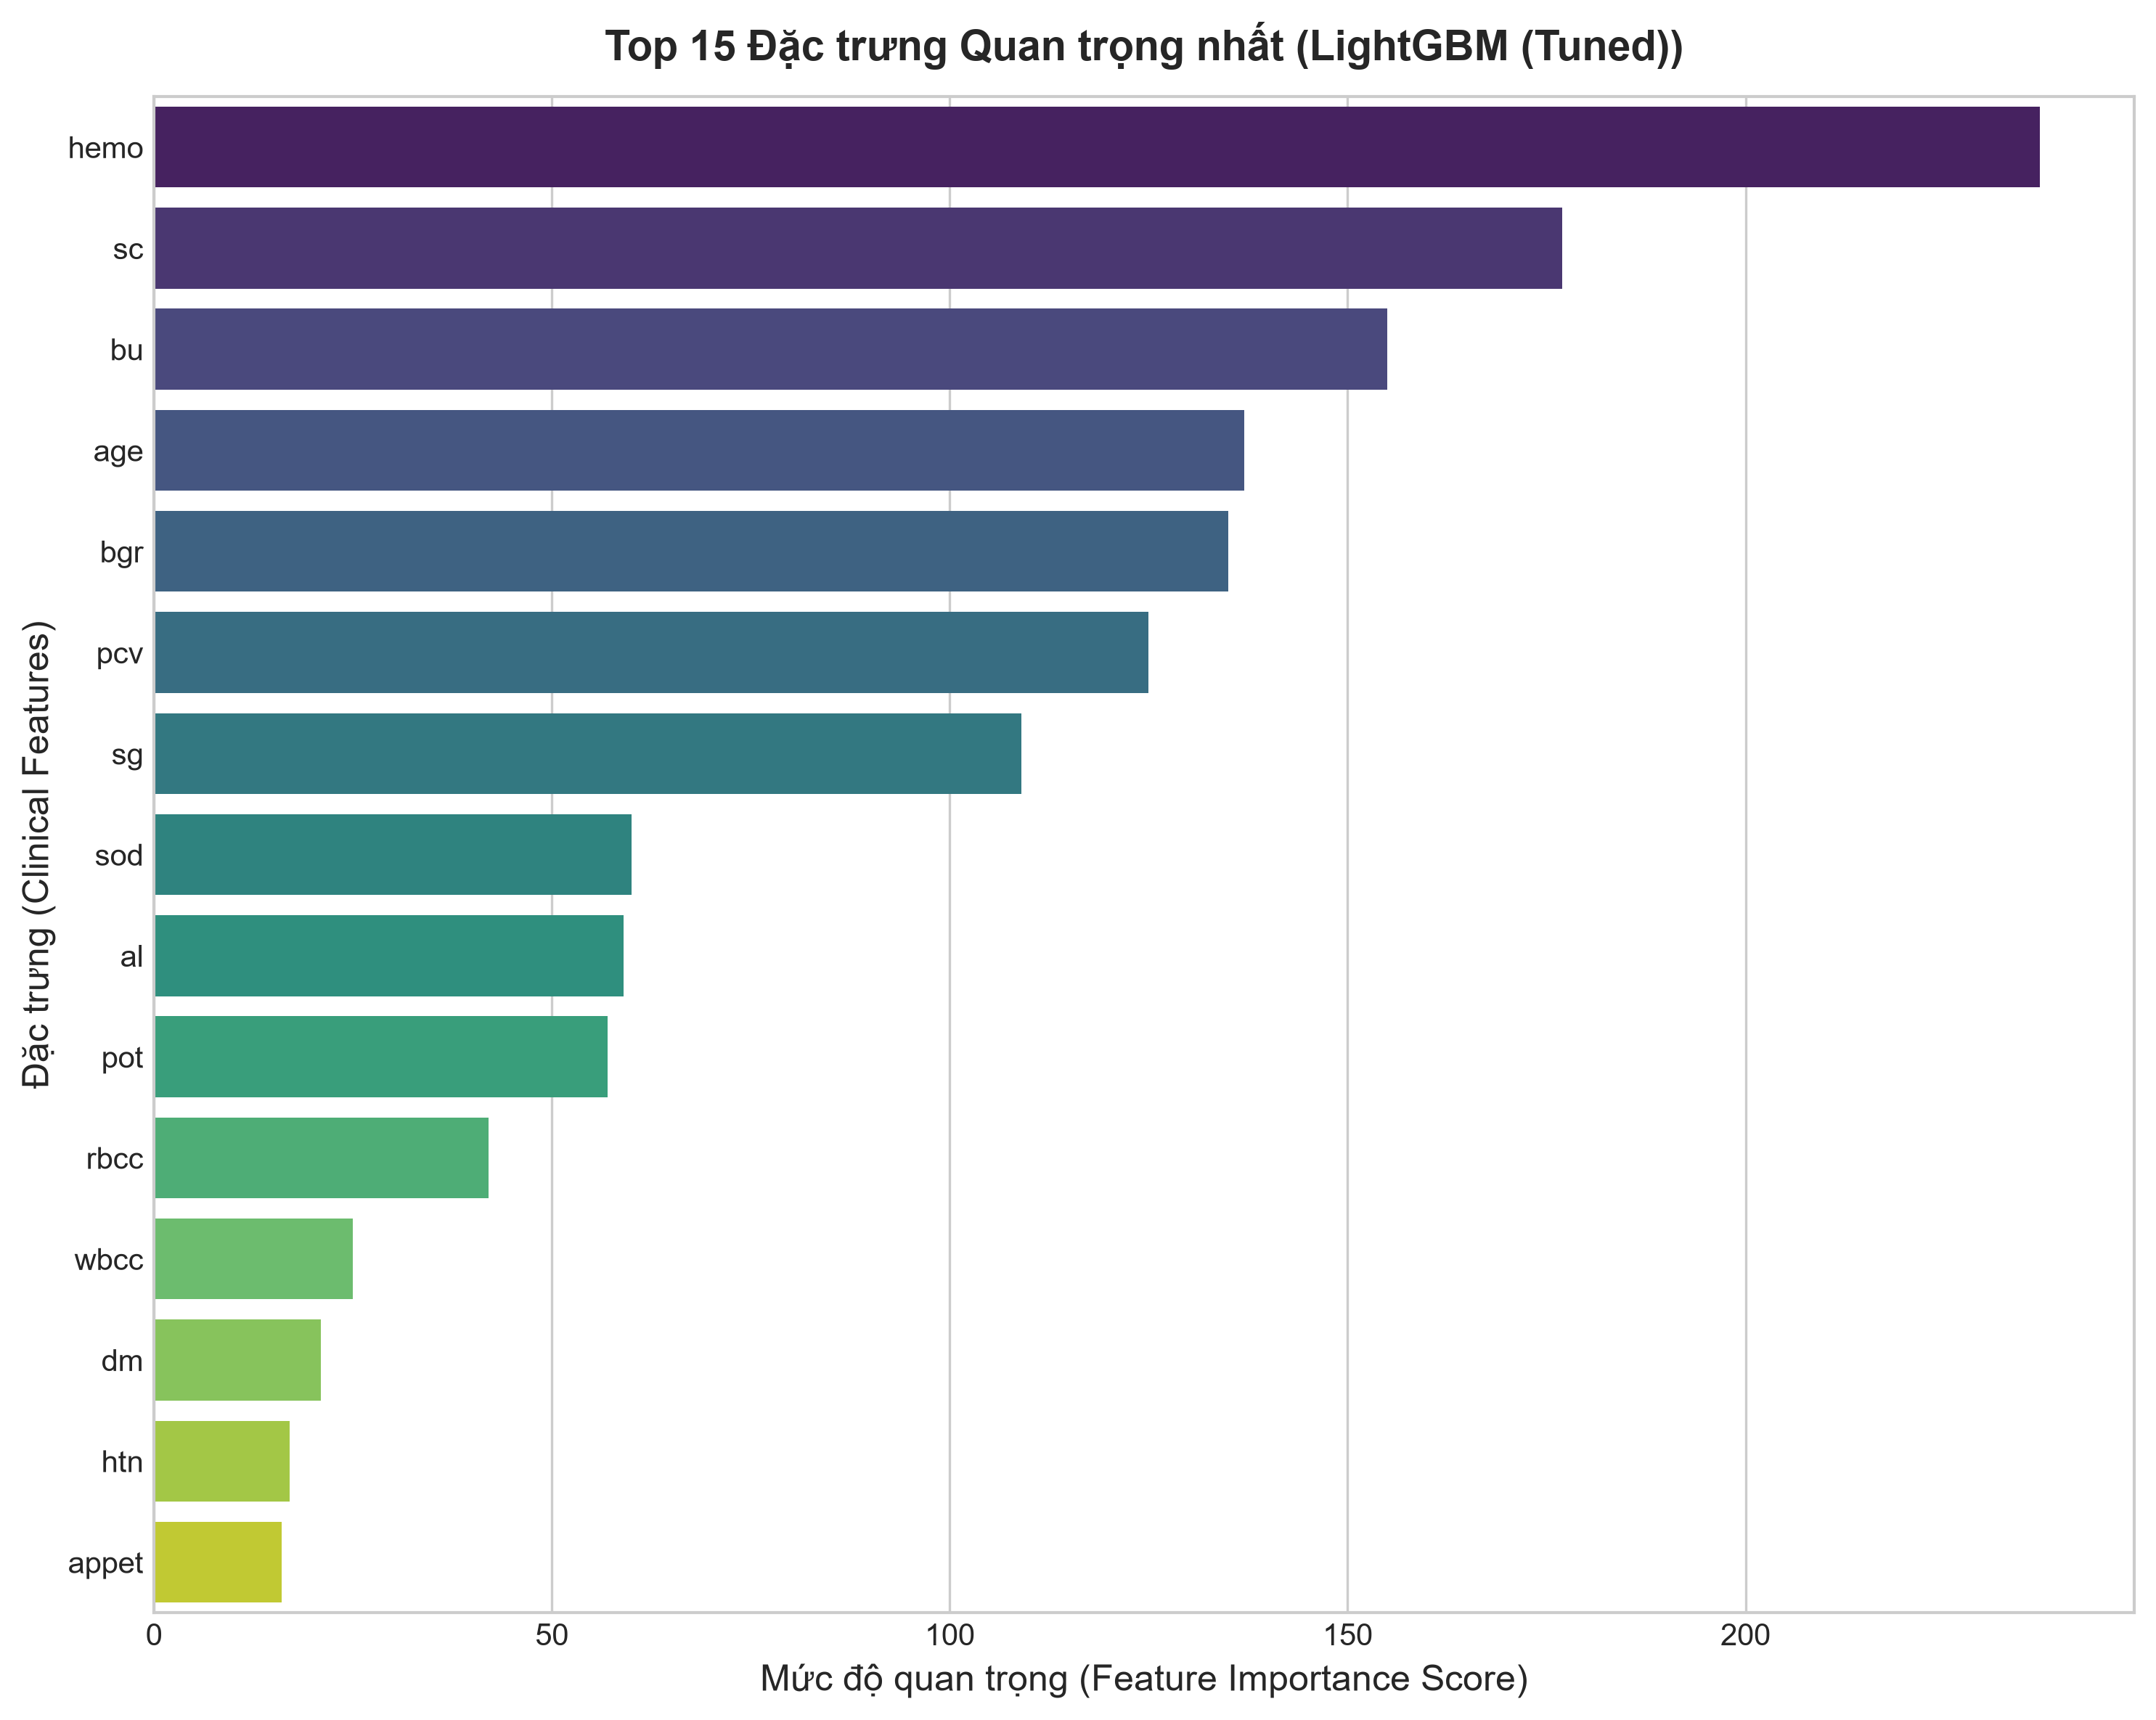

📸 Đã lưu biểu đồ Feature Importance tại: outputs/feature_importance.png
Top 5 đặc trưng có trọng số cao nhất:


,Feature,Importance
14,hemo,237
11,sc,177
10,bu,155
0,age,137
9,bgr,135


In [9]:
# Chọn mô hình tốt hơn giữa Random Forest và LightGBM đã tối ưu
if rf_best_acc >= lgbm_best_acc:
    best_tree_for_fi = rf_best
    best_tree_name = "Random Forest (Tuned)"
else:
    best_tree_for_fi = lgbm_best
    best_tree_name = "LightGBM (Tuned)"

print(f"📌 Sử dụng mô hình [{best_tree_name}] để trích xuất Feature Importance.")

# Tạo DataFrame mức độ quan trọng đặc trưng
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree_for_fi.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Trực quan hóa Top 15 đặc trưng quan trọng nhất
plt.figure(figsize=(10, 8), dpi=300)
palette = sns.color_palette("viridis", n_colors=15)
sns.barplot(data=fi_df.head(15), x='Importance', y='Feature', palette=palette)

plt.title(f"Top 15 Đặc trưng Quan trọng nhất ({best_tree_name})", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Mức độ quan trọng (Feature Importance Score)", fontsize=12)
plt.ylabel("Đặc trưng (Clinical Features)", fontsize=12)
plt.tight_layout()

fi_img_path = 'outputs/feature_importance.png'
plt.savefig(fi_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Đã lưu biểu đồ Feature Importance tại: {fi_img_path}")
print("Top 5 đặc trưng có trọng số cao nhất:")
display(fi_df.head(5))


### Phần 10 — Lưu Mô hình & Tập Dữ liệu Bàn giao
- Tổng hợp bảng so sánh kết quả của tất cả các mô hình cây.
- Xác định mô hình tốt nhất tổng thể.
- Sử dụng `joblib.dump()` để lưu:
  - Mô hình tốt nhất $
ightarrow$ `outputs/best_model.pkl` (để TV3 dùng giải thích XAI với SHAP/LIME).
  - Dữ liệu kiểm thử $
ightarrow$ `outputs/test_data.pkl` (chứa `X_test`, `y_test` để đảm bảo TV3 đánh giá trên cùng tập dữ liệu).


In [10]:
# Bảng tổng kết hiệu năng
summary_results = {
    'Decision Tree (Baseline)': dt_acc,
    'Random Forest (Baseline)': rf_acc,
    'LightGBM (Baseline)': lgbm_acc,
    'Random Forest (Tuned)': rf_best_acc,
    'LightGBM (Tuned)': lgbm_best_acc
}

summary_df = pd.DataFrame(list(summary_results.items()), columns=['Mô hình', 'Test Accuracy'])
summary_df['Accuracy (%)'] = (summary_df['Test Accuracy'] * 100).round(2)
summary_df = summary_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print("📊 BẢNG TỔNG HỢP KẾT QUẢ NHÓM MÔ HÌNH CÂY (TV2):")
display(summary_df)

# Xác định mô hình tốt nhất
best_model_name = summary_df.iloc[0]['Mô hình']
model_map = {
    'Decision Tree (Baseline)': dt_baseline,
    'Random Forest (Baseline)': rf_baseline,
    'LightGBM (Baseline)': lgbm_baseline,
    'Random Forest (Tuned)': rf_best,
    'LightGBM (Tuned)': lgbm_best
}
best_model = model_map[best_model_name]

print()
print(f"🏆 Mô hình xuất sắc nhất được lựa chọn: [{best_model_name}] với Accuracy: {summary_df.iloc[0]['Accuracy (%)']}%")

# Lưu mô hình tốt nhất
best_model_file = 'outputs/best_model.pkl'
joblib.dump(best_model, best_model_file)
print(f"💾 Đã lưu mô hình tốt nhất tại: {best_model_file}")

# Lưu tập test data để TV3 dùng chung
test_data_file = 'outputs/test_data.pkl'
joblib.dump({'X_test': X_test, 'y_test': y_test}, test_data_file)
print(f"💾 Đã lưu tập kiểm thử tại: {test_data_file}")

print("🎉 HOÀN THÀNH TẤT CẢ CÁC NHIỆM VỤ CỦA THÀNH VIÊN 2! Sẵn sàng bàn giao cho Thành viên 3.")


### Phần 11 — Phân Tích Độ Nhạy Siêu Tham Số (Hyperparameter Sensitivity Analysis)
Thực nghiệm kiểm chứng sự thay đổi của độ chính xác khi điều chỉnh các siêu tham số cốt lõi:
- **Tốc độ học (`learning_rate`) của LightGBM:** Minh họa hiện tượng **Underfitting** khi giá trị quá nhỏ (mô hình học chậm, chưa kịp hội tụ).
- **Độ sâu tối đa (`max_depth`) của Decision Tree:** Minh họa hiện tượng **Underfitting** (cây quá nông) và **Overfitting** (cây học vẹt đạt 100% train nhưng giảm trên test).
- Xuất biểu đồ đường trực quan hóa xu hướng biến thiên (`outputs/hyperparameter_sensitivity.png`) phục vụ cho **Chương 4.4** của báo cáo.

In [ ]:
# === PHẦN 11: PHÂN TÍCH ĐỘ NHẠY SIÊU THAM SỐ ===

# 1. Khảo sát Tốc độ học (learning_rate) trên LightGBM
lr_candidates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lgb_records = []

for lr in lr_candidates:
    m_lgb = LGBMClassifier(learning_rate=lr, n_estimators=100, random_state=42, verbose=-1)
    m_lgb.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, m_lgb.predict(X_train))
    acc_te = accuracy_score(y_test, m_lgb.predict(X_test))
    
    if lr <= 0.001:
        eval_note = 'Underfitting nghiêm trọng (Học quá chậm, rớt >36% acc)'
    elif lr == 0.1:
        eval_note = 'Điểm tối ưu (Độ chính xác cao nhất 98.75%)'
    else:
        eval_note = 'Đạt yêu cầu khá'
        
    lgb_records.append({
        'Learning Rate': lr,
        'Train Accuracy (%)': round(acc_tr * 100, 2),
        'Test Accuracy (%)': round(acc_te * 100, 2),
        'Nhận xét hiện tượng': eval_note
    })

df_sensitivity_lgb = pd.DataFrame(lgb_records)
print('📊 BẢNG 1: KHẢO SÁT ĐỘ NHẠY CỦA LIGHTGBM THEO TỐC ĐỘ HỌC (LEARNING RATE):')
display(df_sensitivity_lgb)
print('-' * 80)

# 2. Khảo sát Độ sâu tối đa (max_depth) trên Decision Tree
depth_candidates = [1, 2, 3, 5, None]
dt_records = []

for d in depth_candidates:
    m_dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    m_dt.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, m_dt.predict(X_train))
    acc_te = accuracy_score(y_test, m_dt.predict(X_test))
    
    if d == 1:
        eval_note = 'Underfitting (Cây quá nông, chỉ hỏi đúng 1 câu)'
    elif d is None:
        eval_note = 'Overfitting (Học vẹt 100% train, test giảm xuống 93.75%)'
    else:
        eval_note = 'Cân bằng tốt giữa độ sâu và tổng quát hóa'
        
    dt_records.append({
        'Max Depth': str(d),
        'Train Accuracy (%)': round(acc_tr * 100, 2),
        'Test Accuracy (%)': round(acc_te * 100, 2),
        'Nhận xét hiện tượng': eval_note
    })

df_sensitivity_dt = pd.DataFrame(dt_records)
print('📊 BẢNG 2: KHẢO SÁT HIỆN TƯỢNG UNDER/OVERFITTING THEO ĐỘ SÂU (DECISION TREE):')
display(df_sensitivity_dt)

# 3. Vẽ biểu đồ so sánh độ nhạy (Sensitivity Curve)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=300)

# Biểu đồ 1: LightGBM
axes[0].plot([str(x) for x in df_sensitivity_lgb['Learning Rate']], df_sensitivity_lgb['Train Accuracy (%)'], marker='o', label='Train Accuracy', color='#1f77b4', linewidth=2.5)
axes[0].plot([str(x) for x in df_sensitivity_lgb['Learning Rate']], df_sensitivity_lgb['Test Accuracy (%)'], marker='s', label='Test Accuracy', color='#d62728', linewidth=2.5, linestyle='--')
axes[0].set_title('Độ nhạy của LightGBM theo Learning Rate', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Tốc độ học (Learning Rate)', fontsize=11)
axes[0].set_ylabel('Độ chính xác (%)', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

# Biểu đồ 2: Decision Tree
axes[1].plot(df_sensitivity_dt['Max Depth'], df_sensitivity_dt['Train Accuracy (%)'], marker='o', label='Train Accuracy', color='#1f77b4', linewidth=2.5)
axes[1].plot(df_sensitivity_dt['Max Depth'], df_sensitivity_dt['Test Accuracy (%)'], marker='s', label='Test Accuracy', color='#d62728', linewidth=2.5, linestyle='--')
axes[1].set_title('Hiện tượng Under/Overfitting theo Max Depth (Decision Tree)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Độ sâu tối đa (Max Depth)', fontsize=11)
axes[1].set_ylabel('Độ chính xác (%)', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='lower right')

plt.tight_layout()
sensitivity_img_path = 'outputs/hyperparameter_sensitivity.png'
plt.savefig(sensitivity_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'📸 Đã xuất biểu đồ phân tích độ nhạy tại: {sensitivity_img_path}')